# 1) Import data and libraries

In [1]:
#import libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import pandas as pd

# Set up matplotlib parameters
plt.rcParams['figure.dpi'] = 150
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128

# Add the parent directory and modules directory to the system path
sys.path.append(os.getcwd()+'/../..')
sys.path.append(os.getcwd()+'/../../modules')

# Import custom modules
from Class_sem2dpack import *
from Stage_module import *


#--------------------------------------------------
#                 USER PARAMETERS
#--------------------------------------------------

# SEM2DPACK Parameters
directory = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/ISS_Test_Tag_osides"
is_overburden = False
fmin, fmax = 0.01, 50.0
SEM = sem2dpack(directory)

# Notebook Parameters
save_figure = False


#--------------------------------------------------

Reading grid information...
Reading header file...
0.001 5001 90
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\ISS/../..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\ISS/../..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\ISS/../..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_c

# 2) Read Data

### Read Input Data

In [2]:
input_signal_path = SEM.directory + '/' + 'SourcesTime_sem2d.tab'
input_signal = np.genfromtxt(open(input_signal_path,'r'))
time_input = input_signal[:,0]
V_input = input_signal[:,1]

### Read Fault Data

dict_keys(['nx', 'nt', 'dt', 'x', 'z', 'st0', 'sn0', 'mu0', 'd', 'v', 'st', 'sn', 'mu'])


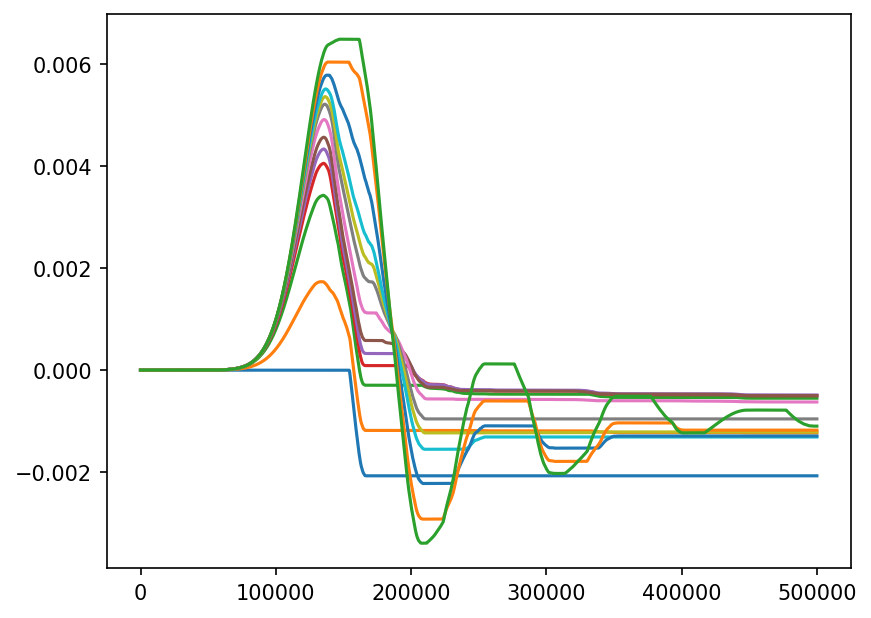

NameError: name 'BC_left' is not defined

In [6]:
# # Read the fault data
# read_fault_testing(SEM, ftag=5)
# BC_bottom = SEM.fault

# read_fault_testing(SEM, ftag=7)
# BC_right = SEM.fault

# read_fault_testing(SEM, ftag=9)
# BC_left = SEM.fault

Flt10 = sem2d_read_fault(directory,"Flt10")

print(Flt10.keys())
plt.plot(Flt10['d'])
plt.show()

# Define the global orientations of the fault components
vector_orientations = {}
vector_orientations['Left'] = -1, -1
vector_orientations['Bottom'] = -1, +1
vector_orientations['Right'] = +1, +1

# Extract the coordinates and slip values for each fault component
X_coord_L = BC_left['x']
X_coord_B = BC_bottom['x']
X_coord_R = BC_right['x']

Z_coord_L = BC_left['z']
Z_coord_B = BC_bottom['z']
Z_coord_R = BC_right['z']

Slip_1_L = BC_left['Slip_1']
Slip_1_B = BC_bottom['Slip_1']
Slip_1_R = BC_right['Slip_1']

Slip_2_L = BC_left['Slip_2']
Slip_2_B = BC_bottom['Slip_2']
Slip_2_R = BC_right['Slip_2']

# Extract the time data
time_fault = BC_left['Time']

# Create a dictionary to hold the fault components with their respective coordinates and slip values
fault_components = {}
fault_components["Left"] = X_coord_L, Z_coord_L, Slip_1_L, Slip_2_L, 'z'
fault_components["Bottom"] = X_coord_B, Z_coord_B, Slip_1_B, Slip_2_B, 'x'
fault_components["Right"] = X_coord_R, Z_coord_R, Slip_1_R, Slip_2_R, 'z'


    

### Read Station Data

In [ ]:
# Read the X component of stations data
SEM.read_seismo('x')
Time_stations = SEM.time
Vx = SEM.velocity[:,:]
Ux = np.zeros(Vx.shape)
for i in range(Vx.shape[1]):
    V = Vx[:,i]
    Ux[:,i] = compute_displacement(V, Time_stations)

# Read the Z component of stations data
SEM.read_seismo('z')
Vz = SEM.velocity[:,:]
Uz = np.zeros(Vz.shape)
for i in range(Vz.shape[1]):
    V = Vz[:,i]
    Uz[:,i] = compute_displacement(V, Time_stations)

# Read stations coordinates
XSTA, ZSTA = SEM.rcoord[:,0], SEM.rcoord[:,1]

# Create a dictionary to hold the components of the stations data
components = {}
components['x'] = Time_stations, Ux, Vx, 'blue'
components['z'] = Time_stations, Uz, Vz, 'red'


# 3) Preview

### Plot Input Signal

In [ ]:
fig, ax_V, ax_U = plot_input_signal(time_input, V_input, 'VU')
plt.show()

if save_figure:
    fig.savefig('Outputs/Input_signal.png', dpi=300, bbox_inches='tight')
    print('Figure saved as Input_signal.png in the directory:', SEM.directory)

In [ ]:
fig2, ax2 = plt.subplots()

# Copier les courbes
for line in ax_U.get_lines():
    ax2.plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), color=line.get_color())

# Copier les titres et labels
ax2.set_title('X '+ax_U.get_title())
ax2.set_xlabel(ax_U.get_xlabel())
ax2.set_ylabel(ax_U.get_ylabel())
ax2.grid(True)
plt.show()

### Drawing of the example with the stations

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(4, 4))

#Desired stations
stations_left = [get_nearest_station(-12,0, XSTA, ZSTA),get_nearest_station(-12,-15, XSTA, ZSTA),get_nearest_station(-12,-30, XSTA, ZSTA)]
stations_bottom = [get_nearest_station(-10,-32, XSTA, ZSTA),get_nearest_station(0,-32, XSTA, ZSTA),get_nearest_station(10,-32, XSTA, ZSTA)]
stations_right = [get_nearest_station(12,0, XSTA, ZSTA),get_nearest_station(12,-15, XSTA, ZSTA),get_nearest_station(12,-30, XSTA, ZSTA)]
stations = np.concatenate([stations_left, stations_bottom, stations_right])

stations_dic = {}
stations_dic["Left"] = stations_left
stations_dic["Bottom"] = stations_bottom
stations_dic["Right"] = stations_right

#Desired fault locations
stations_left_fault = [12, 7, 0]
stations_bottom_fault = [0, 4, 8]
stations_right_fault = [12, 7, 0]


stations_fault_dic = {}
stations_fault_dic["Left"] = stations_left_fault
stations_fault_dic["Bottom"] = stations_bottom_fault
stations_fault_dic["Right"] = stations_right_fault

#Draw the plot
draw_example(ax)
ax.scatter(XSTA, ZSTA, marker='v')
ax.scatter(XSTA[stations], ZSTA[stations], marker='v')
ax.set_title("Drawing of the stations")


# 4) Post-Processing

## Seismograms of the stations

In [ ]:
#stations_index = [1, 6, 11, 17, 18, 19, 5, 10, 15]

def compare_vertical_seismo(comp, val, stations):
    fig = plt.figure()
    fig.suptitle(f"{val}{comp} for different Z values")
    for i,s in enumerate(stations):
        ax = fig.add_subplot(3,1,i+1)
        ax.set_title("X={:.3f}m ; Z={:.3f}m".format(XSTA[s],ZSTA[s]))
        plot_seismogram(ax, s, comp, val, components)
        ax.set_ylabel(None)
        ax.grid(True)
    fig.tight_layout()
    plt.show()

def compare_horizontal_seismo(comp, val, stations):
    fig = plt.figure()
    fig.suptitle(f"{val}{comp} for different X values")
    for i,s in enumerate(stations):
        ax = fig.add_subplot(1,3,i+1)
        ax.set_title("X={:.3f}m ; Z={:.3f}m".format(XSTA[s],ZSTA[s]))
        plot_seismogram(ax, s, comp, val, components)
        ax.set_ylabel(None)
        ax.grid(True)
    fig.tight_layout()
    fig.subplots_adjust(wspace=1)
    plt.show()


compare_vertical_seismo('z', 'U', stations_dic["Left"])
compare_horizontal_seismo('z', 'U', stations_dic["Bottom"])

## Comparison with fault data

In [ ]:
def read_data(comp, station):
    SEM.read_seismo(comp)
    time_rec = SEM.time
    V = SEM.velocity[:,station]
    return time_rec, V

def plot_component(interf, comp):
    fig = plt.figure()
    fig.suptitle(f"{interf} interface {comp.upper()} component comparison")
    fig.supxlabel("Time (s)")
    fig.supylabel("Displacement (m)")
    X_coord, Z_coord, Slip_1, Slip_2, S1_dir = fault_components[interf]
    T, U, V, c = components[comp]
    for i in range(3):
        ax = fig.add_subplot(3,1,i+1)
        if S1_dir==comp:
            ax.plot(time_fault, Slip_1[stations_fault_dic[interf][i],:], label="Interface", c='green')
        else:
            ax.plot(time_fault, Slip_2[stations_fault_dic[interf][i],:], label="Interface", c="green")
        ax.plot(T,U[:,stations_dic[interf][i]], label="Station", c=c)
        ax.legend()
        ax.grid(True)
    fig.tight_layout()

plot_component('Left','x')        
plot_component('Left','z')
plot_component('Bottom','x')        
plot_component('Bottom','z')
plot_component('Right','x')
plot_component('Right','z')



## Deformed structure

In [ ]:
def compute_disp_fault(t, comp):
    X_comp = np.array([])
    Z_comp = np.array([])
    _, _, Slip_1, Slip_2, S1_dir = fault_components[comp]
    if S1_dir=='x':
        X_add = vector_orientations[comp][0]*Slip_1[:,t]
        Z_add= vector_orientations[comp][1]*Slip_2[:,t]
    else :
        X_add = vector_orientations[comp][0]*Slip_2[:,t]
        Z_add = vector_orientations[comp][1]*Slip_1[:,t]
    
    X_comp = np.concatenate([X_comp, X_add])
    Z_comp = np.concatenate([Z_comp, Z_add])
    return X_comp, Z_comp

def compute_deformation(t, scale):
    X_coord, Z_coord = np.array([]), np.array([])
    X_comp, Z_comp = np.array([]), np.array([])
    X_new, Z_new = np.array([]), np.array([])
    for c in fault_components.keys():
        X_coord_c, Z_coord_c, _, _, _ = fault_components[c]
        X_comp_c, Z_comp_c = compute_disp_fault(t, c)
        X_new_c = X_coord_c + scale*X_comp_c
        Z_new_c = Z_coord_c + scale*Z_comp_c
        if c=="Left":
            X_new_c = np.flip(X_new_c)
            Z_new_c = np.flip(Z_new_c)
        X_coord = np.concatenate([X_coord, X_coord_c])
        Z_coord = np.concatenate([Z_coord, Z_coord_c])
        X_comp = np.concatenate([X_comp, X_comp_c])
        Z_comp = np.concatenate([Z_comp, Z_comp_c])
        X_new = np.concatenate([X_new, X_new_c])
        Z_new = np.concatenate([Z_new, Z_new_c])
    return X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new

def draw_fault_deformation(t, ax, scale=100):
    time = time_fault[t]
    ax.set_title(f"Deformed structure at time t={time:.2f}s (scale={scale:.0f})")
    draw_example(ax)
    X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new = compute_deformation(t, scale)
    ax.quiver(X_coord, Z_coord, X_comp, Z_comp, scale=1/scale, scale_units='xy', angles='xy')
    ax.fill(X_new, Z_new, facecolor='none', edgecolor='red', label="Deformed structure at last iteration (receivers data)")

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
draw_fault_deformation(-1, ax, scale=150)
ax.set_xlim([-20,20])
ax.set_ylim([-40,35])
plt.show()

## Animation of the deformed structure

In [ ]:
fig = plt.figure()
fig.subplots_adjust(wspace=1.2, hspace=1)
ax_X = fig.add_subplot(4,5,(1,7))
ax_Z = fig.add_subplot(4,5,(3,9))
cax = fig.add_subplot(4,5,(5,10))
ax_quiver = fig.add_subplot(4,5,(11,19))

plt.rcParams['figure.dpi'] = 100
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128

X_sum = np.concatenate([ np.flip(BC_left['x']), BC_bottom['x'], BC_right['x'] ])
Z_sum = np.concatenate([ np.flip(BC_left['z']), BC_bottom['z'], BC_right['z'] ])

cmap = 'bwr'
bounds = [-0.02,0.02]
scalar_mappable = ScalarMappable(norm=Normalize(bounds[0],bounds[1]), cmap=cmap)
cb = plt.colorbar(scalar_mappable,cax=cax)



def animate(t):
    scale = 150
    time = time_fault[t]

    fig.suptitle(f"Displacement of the structure (t={time:.2f}s)")

    ax_X.cla()
    ax_Z.cla()
    ax_quiver.cla()
    
    X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new = compute_deformation(t, scale)
    
    scalar_mappable = ScalarMappable(norm=Normalize(bounds[0],bounds[1]), cmap=cmap)
    cb.update_normal(scalar_mappable)

    ax_X.scatter(X_coord, Z_coord, c=X_comp, cmap=scalar_mappable.cmap, norm=scalar_mappable.norm)
    ax_X.plot([-100,100],[0,0],c='black',lw=0.6)
    ax_X.set_facecolor('grey')       
    ax_X.set_xlim(-100, 100)
    ax_X.set_ylim(-60, 35)
    ax_X.set_title("X displacement".format(t*1e-5))

    ax_Z.scatter(X_coord, Z_coord, c=Z_comp, cmap=scalar_mappable.cmap, norm=scalar_mappable.norm)
    ax_Z.plot([-100,100],[0,0],c='black',lw=0.6)
    ax_Z.set_facecolor('grey')            
    ax_Z.set_xlim(-100, 100)
    ax_Z.set_ylim(-60, 35)
    ax_Z.set_title("Z displacement".format(t*1e-5))

    
    ax_quiver.set_title(f"Deformed structure(scale={scale:.0f})")
    draw_example(ax_quiver)
    ax_quiver.quiver(X_coord, Z_coord, X_comp, Z_comp, scale=1/scale, scale_units='xy', angles='xy')
    ax_quiver.fill(X_new, Z_new, facecolor='none', edgecolor='red', label="Deformed structure at last iteration (receivers data)")
    ax_quiver.set_xlim([-20,20])
    ax_quiver.set_ylim([-40,35])


anim.FuncAnimation(fig, animate, np.arange(0,500000,5000))

# writervideo = anim.PillowWriter(fps=10)
# animation = anim.FuncAnimation(fig, animate, np.arange(0,500000,5000))
# animation.save('./Displacement_P30.gif', writer=writervideo) 

